<a href="https://colab.research.google.com/github/nunez1405/Data-science-projects/blob/main/CostumerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the data


In [ ]:
import kagglehub

path = kagglehub.dataset_download("vetrirah/customer")

print("Path to dataset files:", path)

100%|██████████| 105k/105k [00:00<00:00, 544kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/vetrirah/customer/versions/1


Import necessary libreries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

In [ ]:
import os

csv_file_path = os.path.join(path, 'Train.csv')
df = pd.read_csv(csv_file_path)

In [ ]:
import os

files = os.listdir(path)
print("Files in the downloaded directory:")
for file in files:
    print(file)

Files in the downloaded directory:
sample_submission.csv
Train.csv
Test.csv


In [ ]:
df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,140
Age,0
Graduated,78
Profession,124
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,76


In [ ]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [ ]:
df.dtypes

,0
ID,int64
Gender,object
Ever_Married,object
Age,int64
Graduated,object
Profession,object
Work_Experience,float64
Spending_Score,object
Family_Size,float64
Var_1,object


In [ ]:
for col in df.columns:
    print(col, df[col].unique())

ID [462809 462643 466315 ... 465406 467299 461879]
Gender ['Male' 'Female']
Ever_Married ['No' 'Yes' nan]
Age [22 38 67 40 56 32 33 61 55 26 19 70 58 41 31 79 49 18 36 35 45 42 83 27
 28 47 29 57 76 25 72 48 74 59 39 51 30 63 52 60 68 86 50 43 80 37 46 69
 78 71 82 23 20 85 21 53 62 75 65 89 66 73 77 87 84 81 88]
Graduated ['No' 'Yes' nan]
Profession ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing' nan]
Work_Experience [ 1. nan  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]
Spending_Score ['Low' 'Average' 'High']
Family_Size [ 4.  3.  1.  2.  6. nan  5.  8.  7.  9.]
Var_1 ['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' nan 'Cat_5']
Segmentation ['D' 'A' 'B' 'C']


Para años de experiencia nulos les ponemos el promedio / In Work_experience column, we replace null values by the mean.

In [ ]:
df['Work_Experience'] = df['Work_Experience'].fillna(df['Work_Experience'].mean())

Para mode_ever_married necesitamos  rellenar con la moda. Filling the column 'Ever_married' in with the mode.

In [ ]:
mode_ever_married = df['Ever_Married'].mode()[0]
df['Ever_Married'] = df['Ever_Married'].fillna(mode_ever_married)

In [ ]:
graduated = df['Graduated'].mode()[0]
df['Graduated'] = df['Graduated'].fillna(graduated)

In [ ]:
profession = df['Profession'].mode()[0]
df['Profession'] = df['Profession'].fillna(profession)

In [ ]:
df['Family_Size'] = df['Family_Size'].fillna(df['Family_Size'].mean())

In [ ]:
df['Var_1'] = df['Var_1'].fillna(df['Var_1'].mode()[0])

Concluimos con el relleno de nulos. Chequeamos.]

In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Profession,0
Work_Experience,0
Spending_Score,0
Family_Size,0
Var_1,0


Empezamos con el método de K-Means

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df= df.drop(columns=['Segmentation'])
df= df.drop(columns=['ID'])

Identifiquemos las variables categoricas y numericas

In [ ]:
# Identify categorical and numerical features
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: Index(['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score',
       'Var_1'],
      dtype='object')
Numerical features: Index(['Age', 'Work_Experience', 'Family_Size'], dtype='object')


Next, we'll create preprocessing pipelines for the categorical and numerical features.

In [ ]:
# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Although we already handled missing values, it's good practice to include this
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Although we already handled missing values, it's good practice to include this
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

Vamos a organizar un pipeline con todas el preprocessing

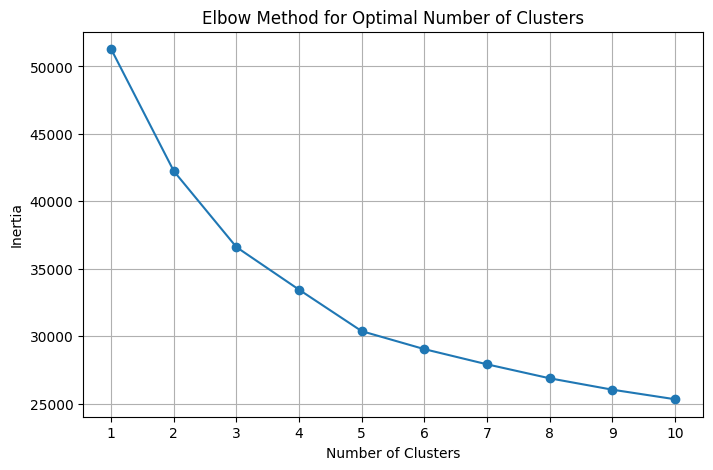

In [ ]:
# Create the K-Means clustering pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('kmeans', KMeans(random_state=42, n_init=10))]) # Added n_init to suppress warning

# Determine the optimal number of clusters using the elbow method
inertia = []
for n_clusters in range(1, 11):
    pipeline.set_params(kmeans__n_clusters=n_clusters)
    pipeline.fit(df)
    inertia.append(pipeline.named_steps['kmeans'].inertia_)

# Plot the elbow method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Now that we have an idea of the optimal number of clusters from the elbow method, we can apply K-Means clustering with the chosen number of clusters. Based on the plot, let's choose 4 clusters.

In [ ]:
# Apply K-Means clustering with the chosen number of clusters (e.g., 4)
optimal_n_clusters = 4
pipeline.set_params(kmeans__n_clusters=optimal_n_clusters)
pipeline.fit(df)

# Add the cluster labels to the original DataFrame
df['Cluster'] = pipeline.named_steps['kmeans'].labels_

# Display the first few rows with the new 'Cluster' column
display(df.head())

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Cluster
0,Male,No,22,No,Healthcare,1.000000,Low,4.0,Cat_4,0
1,Female,Yes,38,Yes,Engineer,2.641663,Average,3.0,Cat_4,2
2,Female,Yes,67,Yes,Engineer,1.000000,Low,1.0,Cat_6,2
3,Male,Yes,67,Yes,Lawyer,0.000000,High,2.0,Cat_6,2
4,Female,Yes,40,Yes,Entertainment,2.641663,High,6.0,Cat_6,0



Analizamos las caracteristicas de cada cluster. Calcularemos el promedio de las variables numericas y la distrbucion por cada cluster

In [ ]:
# Analyze the characteristics of each cluster
print("Cluster sizes:")
print(df['Cluster'].value_counts())

print("\nMean values of numerical features by cluster:")
display(df.groupby('Cluster')[numerical_features].mean())

print("\nDistribution of categorical features by cluster:")
for col in categorical_features:
    print(f"\nDistribution of {col} by cluster:")
    display(df.groupby('Cluster')[col].value_counts(normalize=True).unstack().fillna(0))

Cluster sizes:
Cluster
2    3106
3    1798
0    1694
1    1470
Name: count, dtype: int64

Mean values of numerical features by cluster:


,Age,Work_Experience,Family_Size
Cluster,,,
0,27.305785,1.653502,4.506557
1,37.890476,8.525850,2.445142
2,58.097553,1.191650,2.766601
3,37.978309,1.266764,1.764883



Distribution of categorical features by cluster:

Distribution of Gender by cluster:


Gender,Female,Male
Cluster,,
0,0.432704,0.567296
1,0.525170,0.474830
2,0.361880,0.638120
3,0.568409,0.431591



Distribution of Ever_Married by cluster:


...

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
Cluster,,,,,,,,,
0,0.074970,0.110390,0.086777,0.085006,0.047226,0.515348,0.013577,0.002952,0.063754
1,0.353061,0.087755,0.091156,0.129932,0.062585,0.134014,0.091837,0.014966,0.034694
2,0.413715,0.051513,0.067933,0.112685,0.128461,0.011590,0.013522,0.185448,0.015132
3,0.394327,0.117909,0.115128,0.146830,0.015573,0.125695,0.025584,0.011123,0.047831



Distribution of Spending_Score by cluster:


Spending_Score,Average,High,Low
Cluster,,,
0,0.060803,0.048996,0.890201
1,0.236735,0.109524,0.653741
2,0.453316,0.299099,0.247585
3,0.063960,0.023915,0.912125



Distribution of Var_1 by cluster:


Var_1,Cat_1,Cat_2,Cat_3,Cat_4,Cat_5,Cat_6,Cat_7
Cluster,,,,,,,
0,0.021842,0.095632,0.121015,0.242031,0.015939,0.471665,0.031877
1,0.010884,0.048299,0.096599,0.101361,0.008163,0.710884,0.023810
2,0.013844,0.037347,0.079202,0.100773,0.007083,0.741790,0.019961
3,0.020578,0.040601,0.127364,0.120690,0.013348,0.648498,0.028921


Let's calculate and plot the silhouette scores for different numbers of clusters to evaluate the clustering quality.

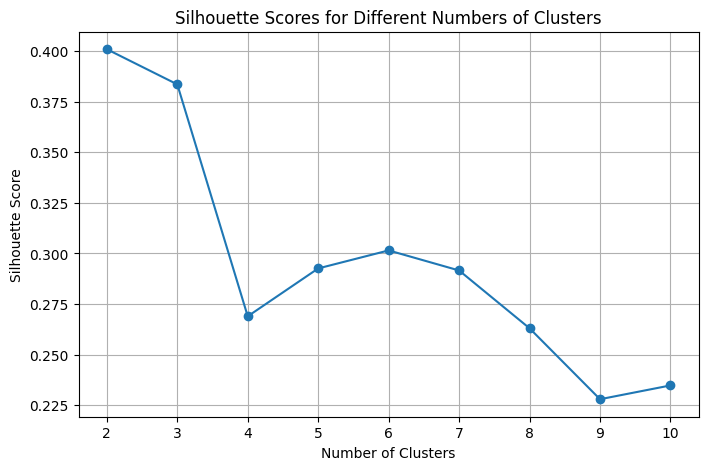

In [ ]:
# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
for n_clusters in range(2, 11): # Silhouette score is not defined for n_clusters = 1
    pipeline.set_params(kmeans__n_clusters=n_clusters)
    pipeline.fit(df.drop(columns=['Cluster'])) # Fit on data without the added 'Cluster' column
    score = silhouette_score(pipeline.transform(df.drop(columns=['Cluster'])), pipeline.named_steps['kmeans'].labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different Numbers of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

Usamos reducción de dimensionalidad en 2D y luego visualizamos graficamente la segmentación


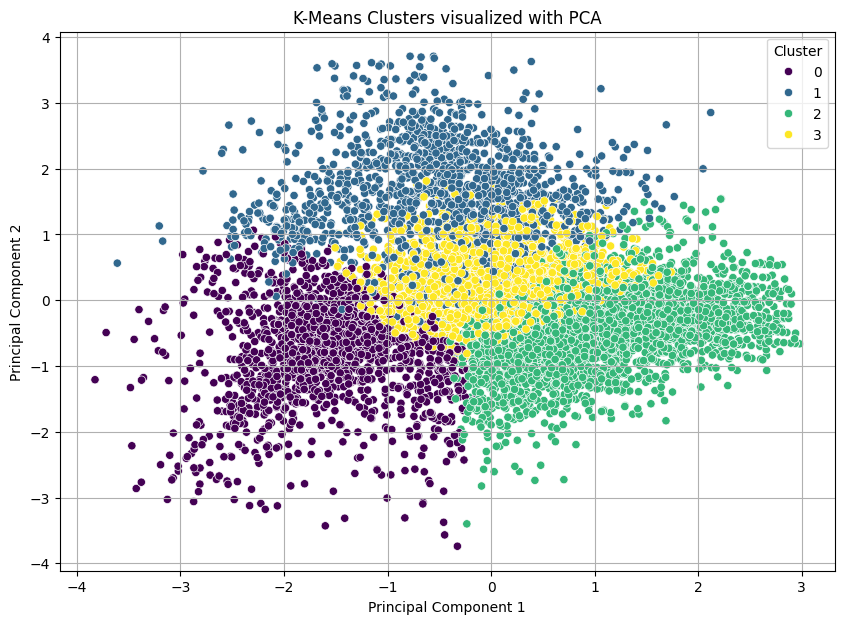

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA for dimensionality reduction
pca = PCA(n_components=2)
# We need to apply the preprocessing steps before PCA
X_preprocessed = pipeline.named_steps['preprocessor'].transform(df.drop(columns=['Cluster']))
X_pca = pca.fit_transform(X_preprocessed)

# Create a new DataFrame with PCA results and cluster labels
pca_df = pd.DataFrame(data = X_pca, columns = ['principal component 1', 'principal component 2'])
pca_df['Cluster'] = df['Cluster']

# Visualize the clusters using a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='principal component 1', y='principal component 2', hue='Cluster', data=pca_df, palette='viridis', legend='full')
plt.title('K-Means Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()